# Math for LLM
Linear algebra and probability from scratch, ending with a mini attention demo.
Every function is written by hand and checked against NumPy.

## Vectors and Embeddings
A vector is a list of numbers. An embedding is a vector that represents meaning.

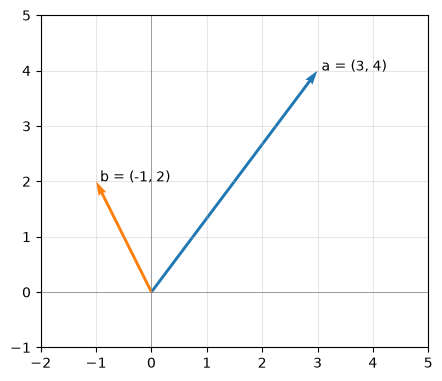

In [2]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([3,4])
b = np.array([-1,2])

fig, ax = plt.subplots(figsize=(5,5))
ax.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='tab:blue')
ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='tab:orange')
ax.text(a[0], a[1], " a = (3, 4)")
ax.text(b[0], b[1], " b = (-1, 2)")

ax.set_xlim(-2, 5)
ax.set_ylim(-1, 5)
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

In [3]:
def magnitude(v):
    total = 0
    for x in v:
        total += x ** 2
    return total ** 0.5

print(magnitude(a))   # 5.0
assert np.allclose(magnitude(a), np.linalg.norm(a))


5.0


In [4]:
def normalize(v):
    m = magnitude(v)
    return np.array([x / m for x in v])

a_unit = normalize(a)
print(a_unit)              # [0.6 0.8]
print(magnitude(a_unit))   # 1.0
assert np.allclose(a_unit, a / np.linalg.norm(a))


[0.6 0.8]
1.0


In [5]:
#[royalty, male, female]
embeddings = {
    "king":   np.array([0.95, 0.85, 0.10]),
    "queen":  np.array([0.93, 0.12, 0.88]),
    "man":    np.array([0.10, 0.90, 0.05]),
    "woman":  np.array([0.08, 0.10, 0.92]),
    "prince": np.array([0.75, 0.80, 0.08]),
    "apple":  np.array([0.02, 0.05, 0.04]),
}

result = embeddings["king"] - embeddings["man"] + embeddings["woman"]
print(result)   # [0.93 0.05 0.97]


[0.93 0.05 0.97]


In [6]:
def distance(u, v):
    return magnitude(u - v)

for word, vec in embeddings.items():
    print(f"{word:7s} {distance(result, vec):.3f}")

closest = min(embeddings, key=lambda w: distance(result, embeddings[w]))
print("closest:", closest)


king    1.182
queen   0.114
man     1.503
woman   0.853
prince  1.178
apple   1.301
closest: queen


### Why this matters for LLMs
LLMs turn text into embeddings. Normalizing keeps only direction (meaning),
and finding the nearest vector is how semantic search and RAG retrieve documents.


## Dot Product and Cosine Similarity
How similar are two vectors? Cosine similarity compares direction only.

In [7]:
def dot_product(u, v):
    total = 0
    for x, y in zip(u, v):
        total += x * y
    return total

print(dot_product(a, b))   # 5
assert np.allclose(dot_product(a, b), np.dot(a, b))

5


In [8]:
def cosine_similarity(u, v):
    return dot_product(u, v) / (magnitude(u) * magnitude(v))

print(cosine_similarity(a, b))   # 0.447
expected = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
assert np.allclose(cosine_similarity(a, b), expected)


0.4472135954999579


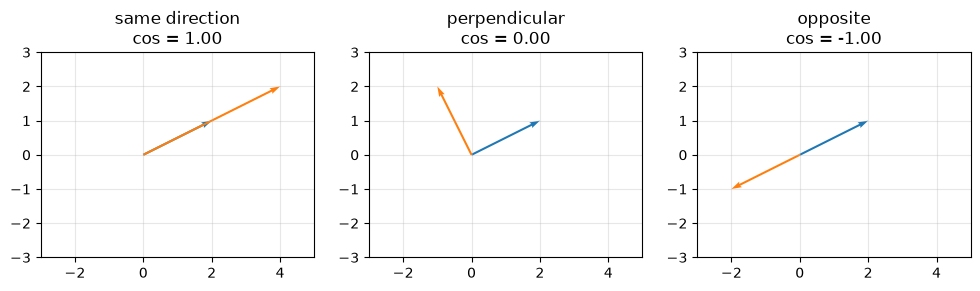

In [9]:
u = np.array([2, 1])
cases = {
    "same direction": np.array([4, 2]),
    "perpendicular":  np.array([-1, 2]),
    "opposite":       np.array([-2, -1]),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, v) in zip(axes, cases.items()):
    ax.quiver(0, 0, u[0], u[1], angles="xy", scale_units="xy", scale=1, color="tab:blue")
    ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="tab:orange")
    ax.set_xlim(-3, 5)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_title(f"{title}\ncos = {cosine_similarity(u, v):.2f}")
plt.show()


In [10]:
p = np.array([3, 4])
q = np.array([1, 7])

print(cosine_similarity(p, q))                  # 0.877
print(dot_product(normalize(p), normalize(q)))  # 0.877
assert np.allclose(cosine_similarity(p, q), dot_product(normalize(p), normalize(q)))


0.8768124086713189
0.8768124086713189


In [11]:
#                                              [money, shipping, account]
docs = {
    "Refund policy: 14 days after purchase":   np.array([0.9, 0.1, 0.1]),
    "Track your package":                      np.array([0.1, 0.9, 0.1]),
    "Reset your password":                     np.array([0.1, 0.1, 0.9]),
    "Shipping fee refund for late delivery":   np.array([0.6, 0.7, 0.0]),
}
query = np.array([0.8, 0.2, 0.1])   # "How do I get my money back?"

scores = {text: cosine_similarity(query, vec) for text, vec in docs.items()}

for text, score in sorted(scores.items(), key=lambda item: item[1], reverse=True):
    print(f"{score:.3f}  {text}")


0.991  Refund policy: 14 days after purchase
0.810  Shipping fee refund for late delivery
0.357  Track your package
0.251  Reset your password


### Why this matters for LLMs
Cosine similarity is how RAG finds relevant documents for a question.
With normalized embeddings, dot product gives the same result and is faster.


## Matrices
A matrix is a grid of numbers. Multiplying by a matrix transforms vectors.


In [12]:
def matvec(M, v):
    return np.array([dot_product(row, v) for row in M])

M = np.array([[2, 0],
              [0, 1]])
v = np.array([1, 3])

print(matvec(M, v))   # [2 3]
assert np.allclose(matvec(M, v), M @ v)


[2 3]


In [13]:
def matmul(A, B):
    n, k = A.shape
    k2, m = B.shape
    assert k == k2, f"shape mismatch: ({n}, {k}) @ ({k2}, {m})"
    C = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            C[i, j] = dot_product(A[i], B[:, j])
    return C

A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])
print(matmul(A, B))   # [[19. 22.] [43. 50.]]
assert np.allclose(matmul(A, B), A @ B)

# test dengan shape yang tidak persegi
rng = np.random.default_rng(0)
X = rng.normal(size=(3, 2))
W = rng.normal(size=(2, 4))
print(matmul(X, W).shape)   # (3, 4)
assert np.allclose(matmul(X, W), X @ W)


[[19. 22.]
 [43. 50.]]
(3, 4)


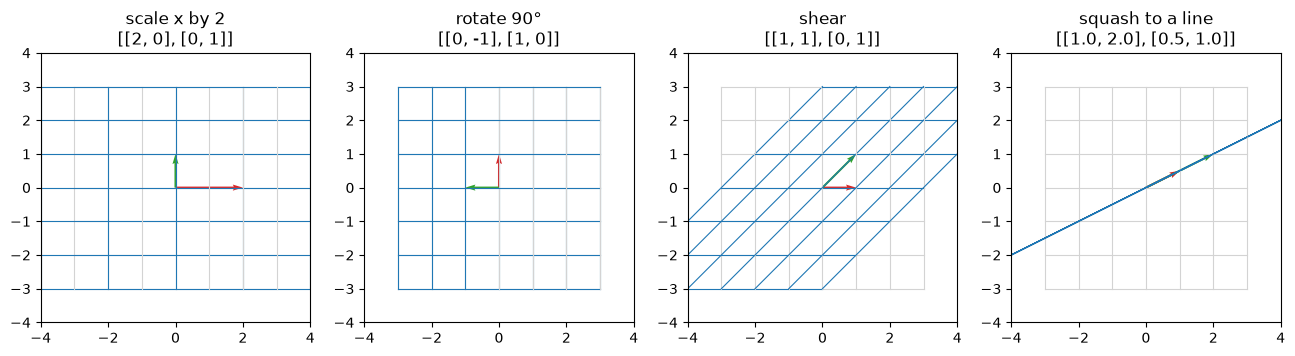

In [14]:
def plot_transform(ax, M, title):
    t = np.linspace(-3, 3, 50)
    for c in np.linspace(-3, 3, 7):
        horizontal = np.array([t, np.full_like(t, c)])   # garis y = c
        vertical = np.array([np.full_like(t, c), t])     # garis x = c
        for line in (horizontal, vertical):
            ax.plot(line[0], line[1], color="lightgray", lw=0.8)
            moved = M @ line
            ax.plot(moved[0], moved[1], color="tab:blue", lw=0.8)

    i_hat = M @ np.array([1, 0])
    j_hat = M @ np.array([0, 1])
    ax.quiver(0, 0, i_hat[0], i_hat[1], angles="xy", scale_units="xy", scale=1, color="tab:red")
    ax.quiver(0, 0, j_hat[0], j_hat[1], angles="xy", scale_units="xy", scale=1, color="tab:green")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title(f"{title}\n{M.tolist()}")

transforms = {
    "scale x by 2":     np.array([[2, 0], [0, 1]]),
    "rotate 90°":       np.array([[0, -1], [1, 0]]),
    "shear":            np.array([[1, 1], [0, 1]]),
    "squash to a line": np.array([[1, 2], [0.5, 1]]),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, M) in zip(axes, transforms.items()):
    plot_transform(ax, M, title)
plt.show()


[[ 0. -1.]
 [ 1.  1.]]
[[ 1. -1.]
 [ 1.  0.]]
RS == SR? False


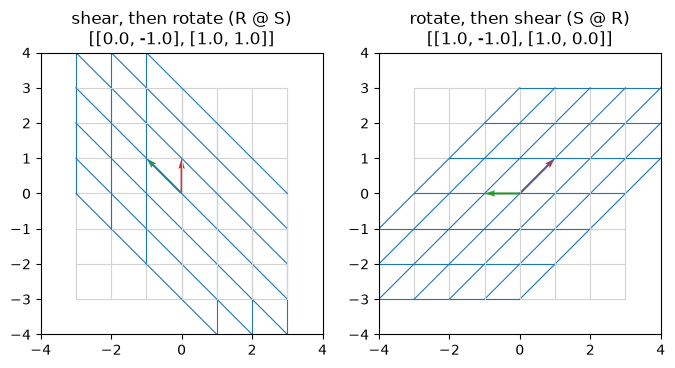

In [15]:
R = np.array([[0, -1], [1, 0]])   # rotate 90°
S = np.array([[1, 1], [0, 1]])    # shear

RS = matmul(R, S)
SR = matmul(S, R)
print(RS)   # [[ 0. -1.] [ 1.  1.]]
print(SR)   # [[ 1. -1.] [ 1.  0.]]
print("RS == SR?", np.allclose(RS, SR))   # False

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_transform(axes[0], RS, "shear, then rotate (R @ S)")
plot_transform(axes[1], SR, "rotate, then shear (S @ R)")
plt.show()


### Why this matters for LLMs
Every LLM layer is a matrix multiplication: token embeddings (n_tokens, d) @ weights (d, d_out).
Model parameters are the numbers inside these matrices, and order matters (AB ≠ BA).


## Probability
LLMs output a probability for every possible next token. Softmax turns scores into probabilities.


In [16]:
def bayes(prior, sensitivity, false_positive_rate):
    p_positive = sensitivity * prior + false_positive_rate * (1 - prior)
    return sensitivity * prior / p_positive

p = bayes(prior=0.01, sensitivity=0.90, false_positive_rate=0.09)
print(f"P(sick | positive) = {p:.1%}")   # 9.2%


P(sick | positive) = 9.2%


In [17]:
rng = np.random.default_rng(0)
n = 1_000_000

sick = rng.random(n) < 0.01
positive = np.where(sick, rng.random(n) < 0.90, rng.random(n) < 0.09)
simulated = sick[positive].mean()

print(f"simulated: {simulated:.1%}")   # sekitar 9.2%
assert np.allclose(p, simulated, atol=0.005)


simulated: 9.2%


In [18]:
import math

def softmax(logits):
    m = max(logits)
    exps = [math.exp(x - m) for x in logits]
    total = sum(exps)
    return np.array([e / total for e in exps])

logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)
print(probs.round(3))   # [0.659 0.242 0.099]
print(probs.sum())      # 1.0

expected = np.exp(logits) / np.exp(logits).sum()
assert np.allclose(probs, expected)

print(softmax(np.array([1000.0, 999.0])).round(3))   # [0.731 0.269]


[0.659 0.242 0.099]
1.0
[0.731 0.269]


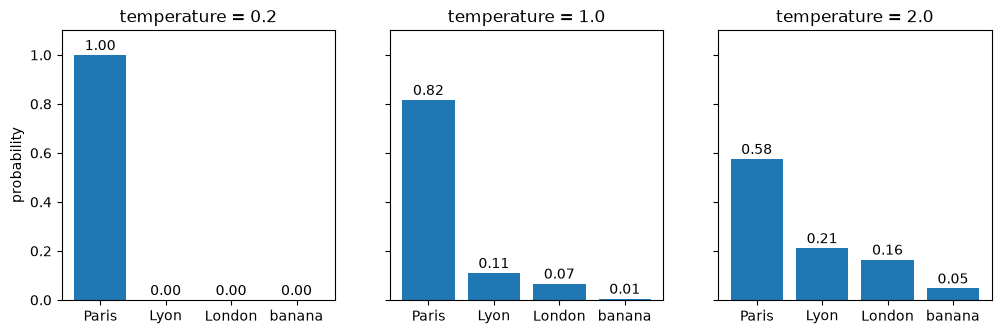

In [19]:
tokens = ["Paris", "Lyon", "London", "banana"]
logits = np.array([4.0, 2.0, 1.5, -1.0])
temperatures = [0.2, 1.0, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, T in zip(axes, temperatures):
    probs = softmax(logits / T)
    ax.bar(tokens, probs, color="tab:blue")
    ax.set_title(f"temperature = {T}")
    ax.set_ylim(0, 1.1)
    for i, prob in enumerate(probs):
        ax.text(i, prob + 0.02, f"{prob:.2f}", ha="center")
axes[0].set_ylabel("probability")
plt.show()


In [20]:
rng = np.random.default_rng(42)
for T in temperatures:
    probs = softmax(logits / T)
    picks = rng.choice(tokens, size=10, p=probs)
    print(f"T={T}: {' '.join(picks)}")


T=0.2: Paris Paris Paris Paris Paris Paris Paris Paris Paris Paris
T=1.0: Paris Lyon Paris Lyon Paris Paris Paris Paris Lyon Paris
T=2.0: Lyon Paris banana London Lyon Paris Paris Paris Paris Lyon


### Why this matters for LLMs
An LLM outputs logits for every token; softmax turns them into probabilities.
Temperature reshapes that distribution before sampling. Bayes reminds us that
base rates matter when judging any classifier, including LLM-based ones.
